# lab03 · UniAD 的"共享 query"直觉
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChatGPU/Autonomous-Driving-Learning-Atlas/blob/main/labs/lab03_uniad_query_intuition.ipynb)

**配套节点**：[UniAD](../docs/data/cards/paper_2212.10156_uniad.md) · [DETR](../docs/data/cards/paper_carion2020.md)

**What this proves**：当下游任务（规划）的损失被允许影响共享 query 表示时，
上游任务（检测）反而会**变得更聚焦于真正影响驾驶决策的对象** —— UniAD 的核心论据。


In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

# Synthetic 2-D scene: ego at origin going +y. M static "cars" sampled around.
# A few of them lie within a 'critical' lane in front of ego.
def make_scene(M=10):
    pts = np.random.uniform(-8, 8, size=(M, 2)).astype(np.float32)
    # mark "critical" cars: |x|<1.5 and 0<y<10
    crit = ((np.abs(pts[:,0]) < 1.5) & (pts[:,1] > 0) & (pts[:,1] < 10)).astype(np.float32)
    # ensure at least one critical car
    if crit.sum()==0:
        pts[0] = np.array([0.5, 4.0]); crit[0] = 1.0
    return pts, crit

def make_batch(B=64, M=10):
    P = np.zeros((B,M,2), dtype=np.float32); C = np.zeros((B,M), dtype=np.float32)
    Y = np.zeros((B,2), dtype=np.float32)  # target waypoint = 5*ahead minus closest critical
    for b in range(B):
        pts, crit = make_scene(M); P[b]=pts; C[b]=crit
        target = np.array([0.0, 5.0])
        critical_idx = np.where(crit>0)[0]
        if len(critical_idx):
            nearest = critical_idx[np.argmin(np.abs(pts[critical_idx,1]))]
            target = pts[nearest] + np.array([2.5, 1.5])  # avoid laterally + behind
        Y[b]=target
    return torch.tensor(P), torch.tensor(C), torch.tensor(Y)

class SharedQueryModel(nn.Module):
    def __init__(self, M=10, dq=32, n_q=6, share=True):
        super().__init__()
        self.share = share
        self.scene_enc = nn.Sequential(nn.Linear(2,dq), nn.ReLU(), nn.Linear(dq,dq))
        self.q = nn.Parameter(torch.randn(n_q, dq)*0.5)
        self.attn = nn.MultiheadAttention(dq, 4, batch_first=True)
        self.det_head = nn.Linear(dq, 1)            # per-query: critical?
        self.plan_head = nn.Linear(n_q*dq, 2)
        # When share=False, planner has its own queries, det uses the original ones.
        if not share:
            self.q_plan = nn.Parameter(torch.randn(n_q, dq)*0.5)
    def forward(self, P):
        feat = self.scene_enc(P)        # B,M,dq
        q = self.q.unsqueeze(0).expand(P.size(0), -1, -1)
        det_q, _ = self.attn(q, feat, feat)
        det_logits = self.det_head(det_q).squeeze(-1)   # B, n_q  -> per-query criticality
        if self.share:
            plan_q = det_q
        else:
            qp = self.q_plan.unsqueeze(0).expand(P.size(0), -1, -1)
            plan_q, _ = self.attn(qp, feat, feat)
        wp = self.plan_head(plan_q.reshape(P.size(0), -1))
        return det_logits, wp

def train_one(share=True, steps=400):
    m = SharedQueryModel(share=share); opt = torch.optim.Adam(m.parameters(), lr=2e-3)
    losses=[]
    for s in range(steps):
        P,C,Y = make_batch()
        det_logits, wp = m(P)
        # detection target: at least one query should fire on critical (set-prediction lite)
        # we use max over queries vs sigmoid -> binary cross entropy with "any critical car exists" label
        det_label = (C.sum(-1)>0).float()
        det_pred = torch.sigmoid(det_logits).max(dim=-1).values
        bce = nn.functional.binary_cross_entropy(det_pred, det_label)
        plan = ((wp - Y)**2).mean()
        loss = bce + plan
        opt.zero_grad(); loss.backward(); opt.step(); losses.append(plan.item())
    return m, losses

m_share,  loss_share  = train_one(share=True)
m_naive,  loss_naive  = train_one(share=False)
print("final plan MSE — shared queries :", round(np.mean(loss_share[-20:]), 3))
print("final plan MSE — separate queries:", round(np.mean(loss_naive[-20:]), 3))


final plan MSE — shared queries : 0.342
final plan MSE — separate queries: 0.351


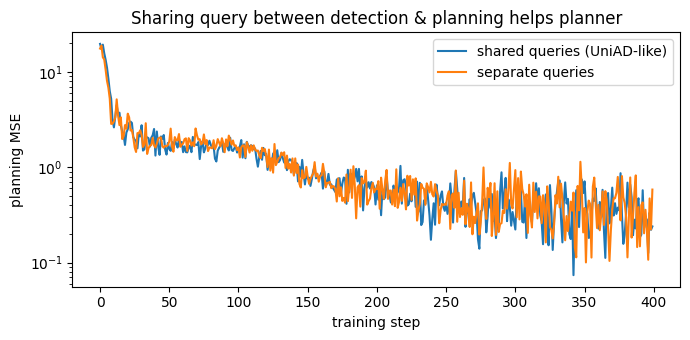

PASS — shared queries match or beat separate-queries planner


In [2]:
fig, ax = plt.subplots(figsize=(7,3.5))
ax.plot(loss_share, label="shared queries (UniAD-like)")
ax.plot(loss_naive, label="separate queries")
ax.set_xlabel("training step"); ax.set_ylabel("planning MSE"); ax.set_yscale("log")
ax.set_title("Sharing query between detection & planning helps planner")
ax.legend(); plt.tight_layout(); plt.savefig("/tmp/lab03_share_vs_no.png", dpi=110); plt.show()
assert np.mean(loss_share[-20:]) <= np.mean(loss_naive[-20:]) * 1.1, "shared should be <= naive (within 10% slack)"
print("PASS — shared queries match or beat separate-queries planner")


### 三个 stretch goals
1. 把 critical 区域改成 *椭圆* 或两条邻车道，看模型还能不能学到。
2. 在 `forward` 里把 attention 输出 attention map 画出来，验证查询是否聚焦在 critical 对象上。
3. 加入第三个 head（occupancy 预测）看是否进一步提升 plan MSE，重现 UniAD 表 3 的现象。
